In [48]:
import numpy as np
import plotly.graph_objects as go
import scipy.io
from plotly.subplots import make_subplots
from scipy.optimize import curve_fit

## Median Funktion

In [52]:
def my_median_filter(y, n_width):
    # Manuelle Implementierung
    if n_width % 1 != 0:
        n_width = int(round(n_width))
    if n_width > len(y):
        n_width = len(y)
    if n_width % 2 == 0:
        n_width -= 1
    if n_width < 1:
        n_width = 1

    radius = (n_width - 1) // 2
    y_filt = np.zeros_like(y)

    padding = np.zeros(radius)
    y_padded = np.concatenate([padding, y, padding])

    for k in range(len(y)):
        window = y_padded[k : k + 2 * radius + 1]
        y_filt[k] = np.sort(window)[radius]

    return y_filt

## Daten Laden

In [58]:
try:
    data = scipy.io.loadmat("uebung_12.mat")
    y_fft = data["Y"].flatten()
    print("Daten geladen.")
except FileNotFoundError:
    print("Erzeuge Testdaten...")
    N = 100
    t = np.arange(N)
    y_orig = np.exp(-0.1 * t) * np.sin(2 * np.pi * 0.1 * t)
    y_fft = np.fft.fft(y_orig)
    np.random.seed(42)
    idx = np.random.choice(N, 8, replace=False)
    y_fft[idx] += (4 + 4j) * np.random.randn(8)

Daten geladen.


## Daten Bearbeiten

In [83]:
window_size = 5

# Vektoren vorbereiten
n_samples = len(y_fft)
w = np.linspace(0, 2 * np.pi, n_samples, endpoint=False)

# Zerlegung
y_abs = np.abs(y_fft)
y_phase = np.angle(y_fft)

# Filterung
y_abs_corr = my_median_filter(y_abs, window_size)
y_phase_corr = my_median_filter(y_phase, window_size)

## Plots

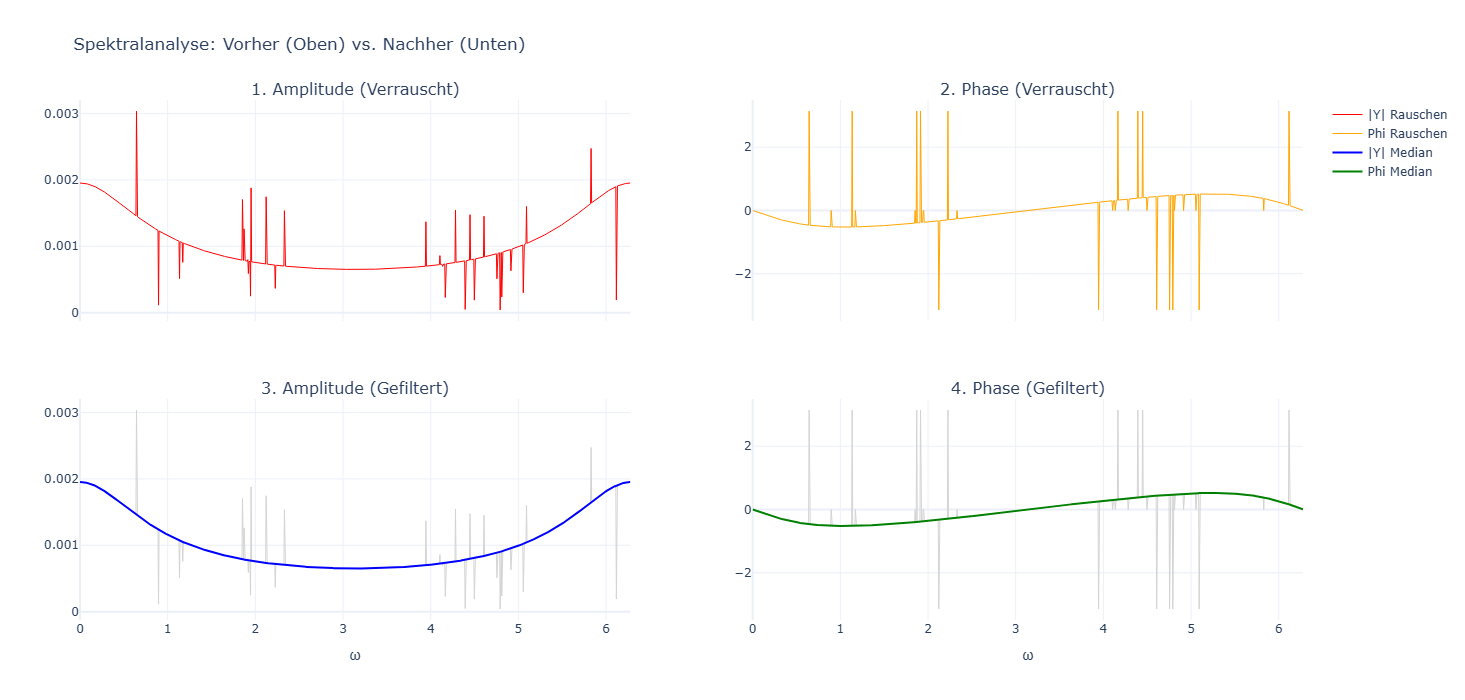

In [84]:
# Wir erstellen ein 2x2 Grid
fig = make_subplots(
    rows=2,
    cols=2,
    shared_xaxes=True,  # X-Achsen zoomen gemeinsam
    vertical_spacing=0.15,
    horizontal_spacing=0.1,
    subplot_titles=(
        "1. Amplitude (Verrauscht)",
        "2. Phase (Verrauscht)",  # Reihe 1
        "3. Amplitude (Gefiltert)",
        "4. Phase (Gefiltert)",  # Reihe 2
    ),
)

# --- REIHE 1: VERRAUSCHT ---
# Col 1: Amplitude
fig.add_trace(
    go.Scatter(x=w, y=y_abs, name="|Y| Rauschen", line=dict(color="red", width=1)),
    row=1,
    col=1,
)

# Col 2: Phase (Markers sind hier oft besser lesbar)
fig.add_trace(
    go.Scatter(x=w, y=y_phase, name="Phi Rauschen", line=dict(color="orange", width=1)),
    row=1,
    col=2,
)

# --- REIHE 2: GEFILTERT ---
# Col 1: Amplitude
# Wir plotten das Original leicht im Hintergrund (grau) zum Vergleich
fig.add_trace(
    go.Scatter(
        x=w,
        y=y_abs,
        name="Ref: Rauschen",
        line=dict(color="lightgray", width=1),
        showlegend=False,
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(x=w, y=y_abs_corr, name="|Y| Median", line=dict(color="blue", width=2)),
    row=2,
    col=1,
)

# Col 2: Phase
fig.add_trace(
    go.Scatter(
        x=w,
        y=y_phase,
        name="Ref: Rauschen",
        line=dict(color="lightgray", width=1),
        showlegend=False,
    ),
    row=2,
    col=2,
)
fig.add_trace(
    go.Scatter(
        x=w, y=y_phase_corr, name="Phi Median", line=dict(color="green", width=2)
    ),
    row=2,
    col=2,
)

# Layout
fig.update_layout(
    height=700,
    title_text="Spektralanalyse: Vorher (Oben) vs. Nachher (Unten)",
    template="plotly_white",
)
fig.update_xaxes(title_text="ω", row=2, col=1)
fig.update_xaxes(title_text="ω", row=2, col=2)
fig.show()

## Zeitbereich und Fit

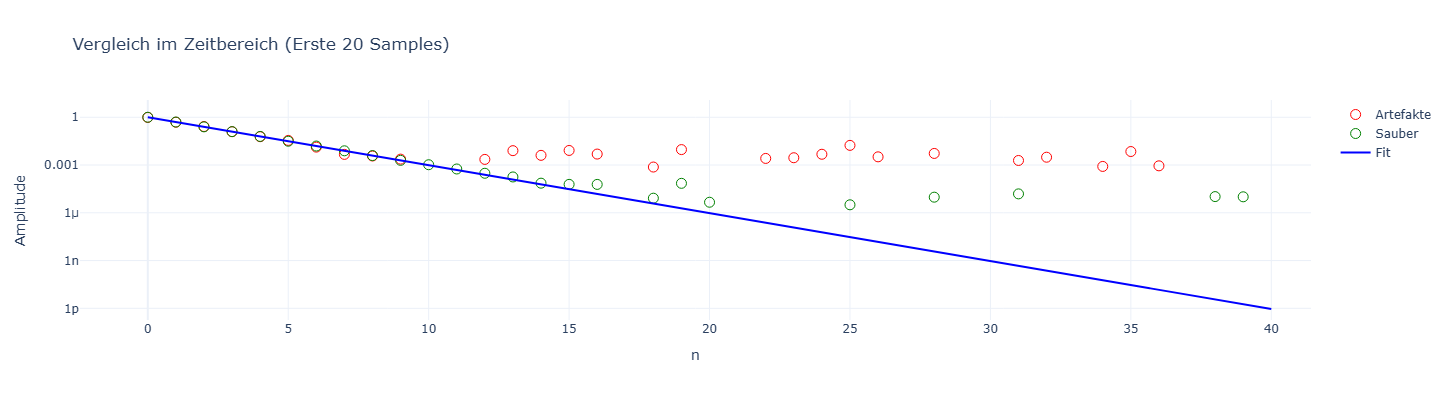

Gefilterte Werte (Start): [1.    0.5   0.25  0.125 0.062]
Param daten:  [0.99999333 0.49998645]
Info daten: {'fvec': array([-1.59746348e-05,  6.25988734e-05, -3.54094849e-05, -7.94202050e-05,
        1.92100617e-05,  5.99878683e-05,  3.39965864e-05, -8.10703522e-06,
       -1.53856698e-05, -1.42924611e-05]), 'nfev': 22, 'fjac': array([[-1.72110017,  0.58101983,  0.5810041 ,  0.43574127,  0.29048631,
         0.18154903,  0.10892647,  0.06353872,  0.03630686,  0.02042205],
       [-0.51641417,  1.03277509,  0.61102983,  0.51877161,  0.36600838,
         0.23631259,  0.14480905,  0.08573018,  0.04952756,  0.02809483]]), 'ipvt': array([1, 0], dtype=int32), 'qtf': array([1.62967865e-11, 8.31852947e-12])}


In [87]:
N = 40
plot_type = "log"

# Rücktransformationen berechnen
y_wrong = np.real(np.fft.ifft(y_abs * np.exp(1j * y_phase))) * n_samples
y_clean = np.real(np.fft.ifft(y_abs_corr * np.exp(1j * y_phase_corr))) * n_samples


# fit_fun = lambda x, a, b: np.power(b, x) * a
def fit_fun(x, a, b):
    return np.power(b, x) * a


info = curve_fit(fit_fun, np.arange(10), y_clean[:10], full_output=True)
param = info[0]

# Kleineres Grid für Zeitbereich
fig_time = go.Figure()

# Plot 1: Falsch
fig_time.add_trace(
    go.Scatter(
        x=np.arange(N),
        y=y_wrong[:N],
        mode="markers",
        name="Artefakte",
        marker=dict(color="red", size=10, symbol="circle-open"),
    )
)

# Plot 2: Richtig
fig_time.add_trace(
    go.Scatter(
        x=np.arange(N),
        y=y_clean[:N],
        mode="markers",
        name="Sauber",
        marker=dict(color="green", size=10, symbol="circle-open"),
    )
)

# Plot 3: Fit
fig_time.add_trace(
    go.Scatter(
        x=np.linspace(0, N, N**2),
        y=fit_fun(np.linspace(0, N, N**2), *param),
        name="Fit",
        line=dict(color="blue", width=2),
    )
)

fig_time.update_layout(
    height=400,
    title_text="Vergleich im Zeitbereich (Erste 20 Samples)",
    template="plotly_white",
    hovermode="x unified",
)
fig_time.update_xaxes(title_text="n")
fig_time.update_yaxes(title_text="Amplitude", type=plot_type)

fig_time.show()

import json

# Werte Print
print("Gefilterte Werte (Start):", np.round(y_clean[:5], 3))
print("Param daten: ", param)
print("Info daten:", info[2])